# Arc Radius — Combined Relevance + Stance Classification
**SageMaker Studio Notebook**

Two-stage classification pipeline:
1. **Relevance** (LegalBERT): Is this bill LGBTQ+ related? (text-only)
2. **Stance** (Logistic Regression): Is it supportive or harmful? (political context features)

Both models are packaged together and deployed behind a single SageMaker serverless endpoint with a custom `inference.py`.

## 1: Imports and Device Setup

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertModel, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, accuracy_score
)
import joblib
import os, json, tarfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

2026-03-16 05:35:08.282229: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 05:35:08.368265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773639308.393906     300 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773639308.402915     300 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 05:35:08.559328: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Device: cuda


## 2: Configuration

In [3]:
# Relevance threshold (tuned to minimize false positives)
RELEVANCE_THRESHOLD = 0.60

# Model
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

# S3 paths
BUCKET = 'arc-radius-s3-bucket'
PATH_LGBTQ_CSV = f's3://{BUCKET}/processed/matched-bills/matched_lgbtq_bills.csv'
PATH_ALL_BILLS_CSV = f's3://{BUCKET}/raw/legiscan-bulk/all_bills_2021_2026.csv'

## 3: Data Loading

In [4]:
# Positive: matched LGBTQ+ bills
lgbtq = pd.read_csv(PATH_LGBTQ_CSV)
lgbtq['label_id'] = 1

# Negative: random sample from unmatched LegiScan bills (2:1 ratio)
all_bills = pd.read_csv(PATH_ALL_BILLS_CSV, engine='python', on_bad_lines='skip')
non_lgbtq = all_bills[~all_bills['bill_id'].isin(lgbtq['bill_id'])].sample(
    n=len(lgbtq) * 2, random_state=42
)
non_lgbtq['label_id'] = 0

# Combine and shuffle
df = pd.concat([lgbtq, non_lgbtq]).sample(frac=1, random_state=42)

# Create text field: title + description
df['text'] = df['title'].fillna('') + '. ' + df['description'].fillna('')

print(f"Total bills: {len(df)}")
print(f"  LGBTQ+:     {(df['label_id']==1).sum()}")
print(f"  Non-LGBTQ+: {(df['label_id']==0).sum()}")

Total bills: 6120
  LGBTQ+:     2040
  Non-LGBTQ+: 4080


## 4: Feature Engineering
Compute political context features needed for the stance classifier.
These are derived from ALL bills (not just LGBTQ+) to capture the state-level political atmosphere.

In [5]:
# Parse year from status_date
df['year'] = pd.to_datetime(df['status_date'], errors='coerce').dt.year
df['year'] = df['year'].fillna(df['year'].median()).astype('Int64')

# Parse sponsor party counts
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}
    parties = [p.strip() for p in str(party_str).split('|')]
    return {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D', ''))
    }

party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']

# Dominant party per bill
def get_dominant(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == row['d_sponsors'] and row['r_sponsors'] > 0:
        return 'Bipartisan'
    return 'Other'

df['dominant_party'] = df.apply(get_dominant, axis=1)

print("--- Dominant Party Distribution ---")
print(df['dominant_party'].value_counts())

--- Dominant Party Distribution ---
dominant_party
R             3394
D             2271
Other          303
Bipartisan     152
Name: count, dtype: int64


## 5: State-Year Political Profiles

In [6]:
# Aggregate all bills by state-year to build political atmosphere scores
state_year_profiles = df.groupby(['state', 'year']).agg(
    total_bills=('bill_id', 'count'),
    r_sponsored_bills=('dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('dominant_party', lambda x: (x == 'Bipartisan').sum()),
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

# R sponsorship ratio: >0.5 = R-leaning legislature
state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['state_r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)

# Bipartisan ratio
state_year_profiles['bipartisan_ratio'] = (
    state_year_profiles['bipartisan_bills'] /
    state_year_profiles['total_bills']
)

# Use most recent year per state as the "current" lean
state_lean = (
    state_year_profiles
    .sort_values('year')
    .groupby('state')
    .tail(1)[['state', 'year', 'state_r_sponsorship_ratio']]
)
state_lean['state_R_leaning'] = state_lean['state_r_sponsorship_ratio'] > 0.5

# Merge state lean back into main df
df = df.merge(
    state_lean[['state', 'state_R_leaning', 'state_r_sponsorship_ratio']],
    on='state', how='left'
)

# Voting percentages
df['percent_yea'] = df['total_yea'] / (df['total_yea'] + df['total_nay'])
df['percent_nay'] = df['total_nay'] / (df['total_yea'] + df['total_nay'])
df['percent_yea'] = df['percent_yea'].fillna(0)
df['percent_nay'] = df['percent_nay'].fillna(0)

print(f"\nState lean merged. NaN check:")
print(df[['state_r_sponsorship_ratio', 'state_R_leaning']].isna().sum())
print(f"\n--- Sample State Leans ---")
print(state_lean.sort_values('state_r_sponsorship_ratio', ascending=False).head(10).to_string(index=False))


State lean merged. NaN check:
state_r_sponsorship_ratio    0
state_R_leaning              0
dtype: int64

--- Sample State Leans ---
state  year  state_r_sponsorship_ratio  state_R_leaning
   DE  2026                        1.0             True
   ND  2025                        1.0             True
   SD  2026                        1.0             True
   WY  2025                        1.0             True
   AK  2025                        1.0             True
   MD  2026                        1.0             True
   UT  2026                        1.0             True
   MI  2026                        1.0             True
   TN  2026                        1.0             True
   KS  2026                        1.0             True


## 6: Train/Test Split
Stratified split to preserve the 33% LGBTQ+ ratio in both sets.
**Important:** Same split used for both relevance and stance evaluation.

In [7]:
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label_id'], random_state=42
)

print(f"Train: {len(train_df)} ({train_df['label_id'].mean()*100:.1f}% LGBTQ+)")
print(f"Test:  {len(test_df)} ({test_df['label_id'].mean()*100:.1f}% LGBTQ+)")

Train: 4896 (33.3% LGBTQ+)
Test:  1224 (33.3% LGBTQ+)


---
# Part 1: Relevance Classifier (LegalBERT)
Text-only model — no metadata features (avoids data leakage).

## 7: Load LegalBERT Tokenizer + Base Model

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = BertModel.from_pretrained(MODEL_NAME).to(device)

# Sanity check
test_inputs = tokenizer(
    "An act prohibiting gender transition procedures for minors",
    return_tensors="pt"
).to(device)
test_outputs = base_model(**test_inputs)
print(f"LegalBERT hidden size: {test_outputs.last_hidden_state.shape[-1]}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

LegalBERT hidden size: 768


## 8: Token Length Analysis

In [9]:
token_lengths = []
for _, row in df.iterrows():
    text = str(row['text']).strip()
    if text:
        toks = tokenizer(text)['input_ids']
        token_lengths.append(len(toks))

token_lengths = np.array(token_lengths)
print("TOKEN LENGTH DISTRIBUTION")
print("=" * 50)
print(f"  Min:    {token_lengths.min()}")
print(f"  25th:   {np.percentile(token_lengths, 25):.0f}")
print(f"  Median: {np.percentile(token_lengths, 50):.0f}")
print(f"  75th:   {np.percentile(token_lengths, 75):.0f}")
print(f"  95th:   {np.percentile(token_lengths, 95):.0f}")
print(f"  Max:    {token_lengths.max()}")

MAX_LEN = 256  # covers title + description with minimal truncation
print(f"\nUsing MAX_LEN = {MAX_LEN}")

Token indices sequence length is longer than the specified maximum sequence length for this model (613 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH DISTRIBUTION
  Min:    7
  25th:   33
  Median: 49
  75th:   79
  95th:   189
  Max:    9489

Using MAX_LEN = 256


## 9: Dataset + Model Definition

In [10]:
class BillDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=256):
        self.data = []
        for _, row in dataframe.iterrows():
            text = str(row['text']).strip()
            if not text:
                continue
            encoded = tokenizer(
                text, return_tensors='pt',
                max_length=max_len, truncation=True, padding='max_length'
            )
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(0).to(device),
                'attention_mask': encoded['attention_mask'].squeeze(0).to(device),
                'label': torch.tensor(row['label_id'], dtype=torch.float32, device=device)
            })
        print(f"  Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        return torch.squeeze(self.linear(cls_output))


# Create datasets and loaders
print("Building train set...")
train_dataset = BillDataset(train_df, tokenizer, max_len=MAX_LEN)
print("Building test set...")
test_dataset = BillDataset(test_df, tokenizer, max_len=MAX_LEN)

BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
relevance_model = LegalBERTClassifier(base_model).to(device)

# pos_weight=3.0 tuned to balance FP vs FN (2.5 and 3.0 tested, 3.0 chosen)
pos_weight = torch.tensor([3.0]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Sanity check
batch = next(iter(train_loader))
out = relevance_model(batch['input_ids'], batch['attention_mask'])
loss = loss_fn(out, batch['label'])
print(f"\nSanity check — output: {out.shape}, loss: {loss.item():.4f}")
print(f"pos_weight = {pos_weight.item()}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Building train set...
  Loaded 4896 examples
Building test set...
  Loaded 1224 examples

Sanity check — output: torch.Size([8]), loss: 1.6789
pos_weight = 3.0
Train samples: 4896
Test samples:  1224


## 10: Training Loops

In [11]:
def train_loop(dataloader, model, loss_fn, optimizer, reporting_interval=50):
    model.train()
    epoch_loss, total_batches = 0, 0
    for batch_idx, data in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(data['input_ids'], data['attention_mask'])
        loss = loss_fn(outputs, data['label'])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        total_batches += 1
        if (batch_idx + 1) % reporting_interval == 0:
            print(f"  Batch {batch_idx+1}: avg loss = {epoch_loss / total_batches:.4f}")
    print(f"  Train loss: {epoch_loss / max(total_batches, 1):.4f}")


def eval_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data in dataloader:
            outputs = model(data['input_ids'], data['attention_mask'])
            test_loss += loss_fn(outputs, data['label']).item()
            preds = (torch.sigmoid(outputs) >= RELEVANCE_THRESHOLD).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data['label'].cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"  Test loss: {test_loss / len(dataloader):.4f}, Accuracy: {100 * accuracy:.1f}%")
    print("\n" + classification_report(
        all_labels, all_preds,
        target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
    ))

## 11: Fine-Tune LegalBERT (Relevance)

In [12]:
# Phase 1: Freeze BERT, train classifier head only
for param in relevance_model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, relevance_model.parameters()), lr=2e-4
)

print("Phase 1: Classifier head only\n")
for epoch in range(3):
    print(f"Epoch {epoch + 1}/3")
    train_loop(train_loader, relevance_model, loss_fn, optimizer)
    eval_loop(test_loader, relevance_model, loss_fn)
    print()

# Phase 2: Unfreeze last 2 BERT layers for fine-tuning
for param in relevance_model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, relevance_model.parameters()), lr=1e-5
)

print("Phase 2: Fine-tuning last 2 BERT layers\n")
for epoch in range(2):
    print(f"Epoch {epoch + 1}/2")
    train_loop(train_loader, relevance_model, loss_fn, optimizer)
    eval_loop(test_loader, relevance_model, loss_fn)
    print()

print("Done!")

Phase 1: Classifier head only

Epoch 1/3
  Batch 50: avg loss = 1.1748
  Batch 100: avg loss = 1.1477
  Batch 150: avg loss = 1.1440
  Batch 200: avg loss = 1.1329
  Batch 250: avg loss = 1.1203
  Batch 300: avg loss = 1.1108
  Batch 350: avg loss = 1.1108
  Batch 400: avg loss = 1.1075
  Batch 450: avg loss = 1.1017
  Batch 500: avg loss = 1.0979
  Batch 550: avg loss = 1.0952
  Batch 600: avg loss = 1.0895
  Train loss: 1.0884
  Test loss: 1.0468, Accuracy: 71.2%

              precision    recall  f1-score   support

  non-LGBTQ+      0.714     0.947     0.814       816
      LGBTQ+      0.695     0.240     0.357       408

    accuracy                          0.712      1224
   macro avg      0.704     0.594     0.586      1224
weighted avg      0.708     0.712     0.662      1224


Epoch 2/3
  Batch 50: avg loss = 1.0501
  Batch 100: avg loss = 1.0508
  Batch 150: avg loss = 1.0519
  Batch 200: avg loss = 1.0423
  Batch 250: avg loss = 1.0369
  Batch 300: avg loss = 1.0352
  Batc

## 12: Relevance Evaluation

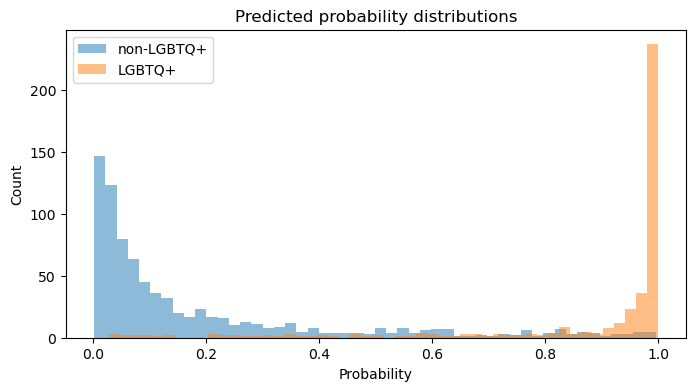

Best F1 threshold: 0.634

Threshold = 0.3:
              precision    recall  f1-score   support

  non-LGBTQ+      0.969     0.801     0.877       816
      LGBTQ+      0.705     0.949     0.809       408

    accuracy                          0.850      1224
   macro avg      0.837     0.875     0.843      1224
weighted avg      0.881     0.850     0.854      1224


Threshold = 0.4:
              precision    recall  f1-score   support

  non-LGBTQ+      0.960     0.853     0.903       816
      LGBTQ+      0.760     0.929     0.836       408

    accuracy                          0.878      1224
   macro avg      0.860     0.891     0.870      1224
weighted avg      0.893     0.878     0.881      1224


Threshold = 0.5:
              precision    recall  f1-score   support

  non-LGBTQ+      0.952     0.879     0.914       816
      LGBTQ+      0.790     0.912     0.846       408

    accuracy                          0.890      1224
   macro avg      0.871     0.895     0.880      

In [13]:
relevance_model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for data in test_loader:
        outputs = relevance_model(data['input_ids'], data['attention_mask'])
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data['label'].cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Probability distribution histogram
plt.figure(figsize=(8, 4))
plt.hist(all_probs[all_labels==0], bins=50, alpha=0.5, label='non-LGBTQ+')
plt.hist(all_probs[all_labels==1], bins=50, alpha=0.5, label='LGBTQ+')
plt.legend()
plt.title("Predicted probability distributions")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (all_probs >= t).astype(int)
    print(f"\nThreshold = {t}:")
    print(classification_report(all_labels, preds,
          target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3))

# Apply chosen threshold
# 0.6 puts accuracy > 90% while keeping FP rate at ~3.3%
all_preds = (all_probs >= RELEVANCE_THRESHOLD).astype(int)
print(f"\n=== Final: Using threshold {RELEVANCE_THRESHOLD} ===")
print(classification_report(all_labels, all_preds, target_names=['non-LGBTQ+', 'LGBTQ+']))

## 13: Relevance Confusion Matrix

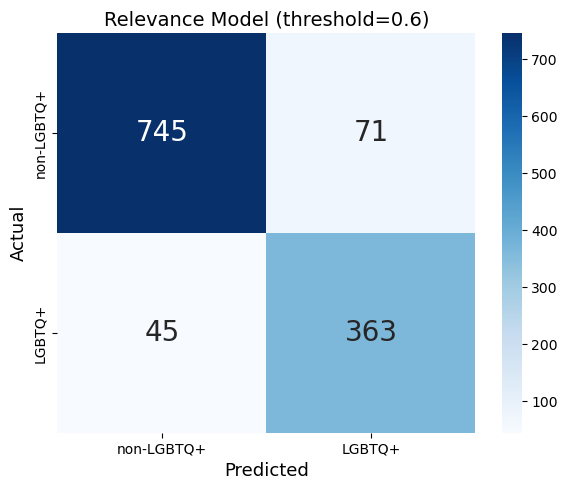

In [14]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-LGBTQ+', 'LGBTQ+'],
            yticklabels=['non-LGBTQ+', 'LGBTQ+'],
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Relevance Model (threshold={RELEVANCE_THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

---
# Part 2: Stance Classifier (Logistic Regression)
Uses political context features — only runs on bills classified as LGBTQ+ relevant.

**Features:** `state_r_sponsorship_ratio`, `dominant_party`, `percent_nay`, `r_sponsors`, `d_sponsors`, `other_sponsors`

**Labels:** harmful (1) vs supportive (0)

## 14: Prepare Stance Training Data

In [15]:
# Stance features (political context only)
STANCE_FEATURES = [
    'state_r_sponsorship_ratio',
    'dominant_party',
    'percent_nay',
    'r_sponsors',
    'd_sponsors',
    'other_sponsors',
]

# Prepare training labels from LGBTQ+ bills in training set
train_df['true_stance'] = train_df['label']
train_df['is_lgbtq'] = train_df['label_id']

# Filter to LGBTQ+ bills only for stance training
df_stance_train = train_df.loc[
    train_df['is_lgbtq'] == 1,
    STANCE_FEATURES + ['true_stance']
].copy()

# Binary target: harmful = 1, supportive = 0
df_stance_train['true_stance'] = (df_stance_train['true_stance'] == 'harmful').astype(int)

# Encode dominant_party as binary (R=1, other=0)
if 'dominant_party' in df_stance_train.columns:
    df_stance_train['dominant_party'] = (df_stance_train['dominant_party'] == 'R').astype(int)

# Same for test set
test_df['true_stance'] = test_df['label']
test_df['is_lgbtq'] = test_df['label_id']

df_stance_test = test_df.loc[
    test_df['is_lgbtq'] == 1,
    STANCE_FEATURES + ['true_stance']
].copy()
df_stance_test['true_stance'] = (df_stance_test['true_stance'] == 'harmful').astype(int)
if 'dominant_party' in df_stance_test.columns:
    df_stance_test['dominant_party'] = (df_stance_test['dominant_party'] == 'R').astype(int)

X_train_stance = df_stance_train.drop(columns='true_stance')
y_train_stance = df_stance_train['true_stance']
X_test_stance = df_stance_test.drop(columns='true_stance')
y_test_stance = df_stance_test['true_stance']

print(f"Stance training: {len(X_train_stance)} LGBTQ+ bills")
print(f"Stance test:     {len(X_test_stance)} LGBTQ+ bills")
print(f"\nFeatures: {STANCE_FEATURES}")
print(f"\nNaN check (train):")
print(df_stance_train.isna().sum())
print(f"\nNaN check (test):")
print(df_stance_test.isna().sum())

Stance training: 1632 LGBTQ+ bills
Stance test:     408 LGBTQ+ bills

Features: ['state_r_sponsorship_ratio', 'dominant_party', 'percent_nay', 'r_sponsors', 'd_sponsors', 'other_sponsors']

NaN check (train):
state_r_sponsorship_ratio    0
dominant_party               0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64

NaN check (test):
state_r_sponsorship_ratio    0
dominant_party               0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64


## 15: Train Stance Classifier

In [16]:
# Fill any remaining NaN
X_train_stance = X_train_stance.fillna(0)
X_test_stance = X_test_stance.fillna(0)

stance_model = LogisticRegression(max_iter=500)
stance_model.fit(X_train_stance, y_train_stance)

y_pred_stance = stance_model.predict(X_test_stance)

print('Stance model (political context features):\n')
print(f"Accuracy: {accuracy_score(y_test_stance, y_pred_stance):.4f}")
print(classification_report(y_test_stance, y_pred_stance, target_names=['supportive', 'harmful']))

# Show feature importances
print("\nFeature coefficients:")
for feat, coef in zip(STANCE_FEATURES, stance_model.coef_[0]):
    direction = "→ harmful" if coef > 0 else "→ supportive"
    print(f"  {feat:30s}  {coef:+.4f}  {direction}")

Stance model (political context features):

Accuracy: 0.9632
              precision    recall  f1-score   support

  supportive       0.97      0.67      0.79        43
     harmful       0.96      1.00      0.98       365

    accuracy                           0.96       408
   macro avg       0.96      0.84      0.89       408
weighted avg       0.96      0.96      0.96       408


Feature coefficients:
  state_r_sponsorship_ratio       +0.8697  → harmful
  dominant_party                  +2.7411  → harmful
  percent_nay                     +2.0833  → harmful
  r_sponsors                      +0.4075  → harmful
  d_sponsors                      -0.4985  → supportive
  other_sponsors                  +0.4065  → harmful


## 16: Combined Pipeline Evaluation
Run both models end-to-end: relevance first, then stance on predicted LGBTQ+ bills.

In [17]:
# Attach relevance predictions to test dataframe
test_df['relevant_pred'] = all_preds

# Run stance on bills predicted as LGBTQ+ relevant
df_stance_final = test_df.loc[
    test_df['relevant_pred'] == 1,
    STANCE_FEATURES + ['true_stance']
].copy()
df_stance_final['true_stance'] = (df_stance_final['true_stance'] == 'harmful').astype(int)
if 'dominant_party' in df_stance_final.columns:
    df_stance_final['dominant_party'] = (df_stance_final['dominant_party'] == 'R').astype(int)

X_final = df_stance_final.drop(columns='true_stance').fillna(0)
y_final = df_stance_final['true_stance']
stance_preds_final = stance_model.predict(X_final)

# Build combined labels
test_df['true_cumulative_label'] = np.where(
    test_df['is_lgbtq'] == True,
    test_df['true_stance'],
    'not applicable'
)

test_df['pred_cumulative_label'] = 'not applicable'
test_df.loc[test_df['relevant_pred'] == 1, 'pred_cumulative_label'] = stance_preds_final
test_df['pred_cumulative_label'] = test_df['pred_cumulative_label'].replace({
    1: 'harmful', 0: 'supportive'
})

print('Combined Pipeline Accuracy (Relevance + Stance):\n')
print(f"Accuracy: {accuracy_score(test_df['true_cumulative_label'], test_df['pred_cumulative_label']):.4f}")
print(classification_report(
    test_df['true_cumulative_label'],
    test_df['pred_cumulative_label']
))

Combined Pipeline Accuracy (Relevance + Stance):

Accuracy: 0.8946
                precision    recall  f1-score   support

       harmful       0.83      0.89      0.86       365
not applicable       0.94      0.91      0.93       816
    supportive       0.58      0.58      0.58        43

      accuracy                           0.89      1224
     macro avg       0.79      0.79      0.79      1224
  weighted avg       0.90      0.89      0.90      1224



---
# Part 3: Package & Deploy to SageMaker
Package both models into a single `model.tar.gz` with a custom `inference.py` that handles the two-stage pipeline.

## 17: Create Custom inference.py

In [30]:
# This file will be included in model.tar.gz
# SageMaker calls model_fn, input_fn, predict_fn, output_fn
#
# The endpoint accepts RAW bill fields and computes all derived
# features internally — Lambda is a dumb pipe.
#
# IMPORTANT: Uses custom LegalBERTClassifier (raw CLS token),
# NOT HuggingFace's AutoModelForSequenceClassification (pooler output).

inference_code = '''
import os
import json
import torch
import joblib
import numpy as np
from transformers import AutoTokenizer, BertModel

# ── Custom model class (must match training exactly) ──
class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        return torch.squeeze(self.linear(cls_output))


# Globals (loaded once when container starts)
relevance_model = None
stance_model = None
state_profiles = None
tokenizer = None
device = None
RELEVANCE_THRESHOLD = 0.60


def model_fn(model_dir):
    """Load all models + state profiles when the endpoint starts."""
    global relevance_model, stance_model, state_profiles, tokenizer, device

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_dir)

    # 2. Load LegalBERT relevance model (custom class, not HF AutoModel)
    checkpoint = torch.load(
        os.path.join(model_dir, 'relevance_model.pt'),
        map_location=device
    )
    base_model = BertModel.from_pretrained(model_dir).to(device)
    relevance_model = LegalBERTClassifier(base_model).to(device)
    relevance_model.load_state_dict(checkpoint['model_state_dict'])
    relevance_model.eval()
    print(f"Loaded relevance model (threshold={RELEVANCE_THRESHOLD})")

    # 3. Load stance model (sklearn LogReg)
    stance_model = joblib.load(os.path.join(model_dir, 'stance_model.joblib'))

    # 4. Load pre-computed state profiles (baked in during packaging)
    profiles_path = os.path.join(model_dir, 'state_profiles.joblib')
    if os.path.exists(profiles_path):
        state_profiles = joblib.load(profiles_path)
        print(f"Loaded state profiles: {len(state_profiles)} states")
    else:
        state_profiles = {}
        print("WARNING: state_profiles.joblib not found, state features will be 0")

    print(f"All models loaded on {device}")
    return relevance_model


def input_fn(request_body, request_content_type):
    """Parse the incoming request."""
    if request_content_type == 'application/json':
        return json.loads(request_body)
    raise ValueError(f"Unsupported content type: {request_content_type}")


def _parse_sponsor_features(sponsor_parties_str):
    """Parse 'R | R | D' into counts + dominant party."""
    if not sponsor_parties_str:
        return 0, 0, 0, 'Other'

    parties = [p.strip() for p in str(sponsor_parties_str).split('|')]
    r = sum(1 for p in parties if p == 'R')
    d = sum(1 for p in parties if p == 'D')
    other = sum(1 for p in parties if p and p not in ('R', 'D'))

    if r > d:
        dominant = 'R'
    elif d > r:
        dominant = 'D'
    elif r == 0 and d == 0:
        dominant = 'Other'
    else:
        dominant = 'Bipartisan'

    return r, d, other, dominant


def predict_fn(input_data, model):
    """Two-stage prediction from raw bill fields.

    Accepts:
        text, state, sponsor_parties, total_yea, total_nay

    Returns:
        lgbtq_related, label, confidence, relevance_score
    """
    text = input_data.get('text', '')

    # Stage 1: Relevance (LegalBERT, text-only)
    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=256, truncation=True, padding='max_length'
    ).to(device)

    with torch.no_grad():
        logit = relevance_model(inputs['input_ids'], inputs['attention_mask'])
        prob = torch.sigmoid(logit).item()

    is_relevant = prob >= RELEVANCE_THRESHOLD

    result = {
        'lgbtq_related': is_relevant,
        'relevance_score': round(prob, 4),
    }

    if not is_relevant:
        result['label'] = 'not_relevant'
        result['confidence'] = round(1 - prob, 4)
        return result

    # Stage 2: Stance (LogReg, political context)
    r_sponsors, d_sponsors, other_sponsors, dominant_party = _parse_sponsor_features(
        input_data.get('sponsor_parties', '')
    )

    try:
        yea = float(input_data.get('total_yea', 0) or 0)
        nay = float(input_data.get('total_nay', 0) or 0)
    except (ValueError, TypeError):
        yea, nay = 0.0, 0.0
    vote_total = yea + nay
    percent_nay = nay / vote_total if vote_total > 0 else 0.0

    state = input_data.get('state', '')
    profile = state_profiles.get(state, {}) if state_profiles else {}
    state_r_sponsorship_ratio = float(profile.get('r_sponsorship_ratio', 0.5))

    features = [
        state_r_sponsorship_ratio,
        1.0 if dominant_party == 'R' else 0.0,
        percent_nay,
        float(r_sponsors),
        float(d_sponsors),
        float(other_sponsors),
    ]

    features_array = np.array([features])
    stance_pred = stance_model.predict(features_array)[0]
    stance_proba = stance_model.predict_proba(features_array)[0]

    label = 'harmful' if stance_pred == 1 else 'supportive'
    confidence = round(float(max(stance_proba)), 4)

    result['label'] = label
    result['confidence'] = confidence
    result['stance_proba'] = {
        'supportive': round(float(stance_proba[0]), 4),
        'harmful': round(float(stance_proba[1]), 4),
    }

    return result


def output_fn(prediction, response_content_type):
    """Format the response."""
    return json.dumps(prediction)
'''

# Save inference.py
with open('inference.py', 'w') as f:
    f.write(inference_code)

print("Created inference.py")
print("\nKey difference from previous version:")
print("  Uses custom LegalBERTClassifier (raw CLS token)")
print("  NOT HuggingFace AutoModelForSequenceClassification (pooler output)")
print("\nEndpoint contract:")
print("  Request:  {'text': '...', 'state': 'TX', 'sponsor_parties': 'R|R|D', 'total_yea': 0, 'total_nay': 0}")
print("  Response: {'lgbtq_related': true, 'label': 'harmful', 'confidence': 0.87, 'relevance_score': 0.94}")

Created inference.py

Key difference from previous version:
  Uses custom LegalBERTClassifier (raw CLS token)
  NOT HuggingFace AutoModelForSequenceClassification (pooler output)

Endpoint contract:
  Request:  {'text': '...', 'state': 'TX', 'sponsor_parties': 'R|R|D', 'total_yea': 0, 'total_nay': 0}
  Response: {'lgbtq_related': true, 'label': 'harmful', 'confidence': 0.87, 'relevance_score': 0.94}


## 18: Package Both Models + State Profiles into model.tar.gz

In [31]:
export_dir = './sagemaker_export'
os.makedirs(export_dir, exist_ok=True)

# ── 1. Save LegalBERT base model + tokenizer (HuggingFace format) ──
# We save the BASE BertModel (not AutoModelForSequenceClassification)
# because inference.py rebuilds the custom LegalBERTClassifier on top of it.
print("1. Saving base BertModel + tokenizer...")
relevance_model.bert.save_pretrained(export_dir)
tokenizer.save_pretrained(export_dir)
print("   Saved base BERT weights + tokenizer")

# ── 2. Save custom model checkpoint (includes classifier head) ──
print("2. Saving relevance model checkpoint...")
checkpoint = {
    'model_state_dict': relevance_model.state_dict(),
    'base_model_name': MODEL_NAME,
    'hidden_size': 768,
    'dropout': 0.3,
}
torch.save(checkpoint, os.path.join(export_dir, 'relevance_model.pt'))
print("   Saved relevance_model.pt")

# ── 3. Save stance model as joblib ──
print("3. Saving stance model...")
joblib.dump(stance_model, os.path.join(export_dir, 'stance_model.joblib'))
print("   Saved stance_model.joblib")

# ── 4. Bake state profiles into model.tar.gz ──
print("4. Saving state profiles...")
state_profiles_dict = (
    state_lean
    .set_index('state')[['state_r_sponsorship_ratio']]
    .to_dict('index')
)
joblib.dump(state_profiles_dict, os.path.join(export_dir, 'state_profiles.joblib'))
print(f"   Saved state_profiles.joblib ({len(state_profiles_dict)} states)")

for st in ['TX', 'CA', 'FL', 'NY']:
    if st in state_profiles_dict:
        ratio = state_profiles_dict[st]['state_r_sponsorship_ratio']
        print(f"     {st}: r_sponsorship_ratio = {ratio:.4f}")

# ── 5. Copy inference.py into export dir ──
print("5. Adding inference.py...")
import shutil

code_dir = os.path.join(export_dir, 'code')
os.makedirs(code_dir, exist_ok=True)
shutil.copy('inference.py', os.path.join(code_dir, 'inference.py'))

with open(os.path.join(code_dir, 'requirements.txt'), 'w') as f:
    f.write('joblib\n')
print("   Added code/inference.py + code/requirements.txt")

# ── 6. Create model.tar.gz ──
print("6. Creating model.tar.gz...")
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    for root, dirs, files in os.walk(export_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, export_dir)
            tar.add(file_path, arcname=arcname)

size_mb = os.path.getsize('model.tar.gz') / (1024 * 1024)
print(f"\nDone! model.tar.gz = {size_mb:.1f} MB")
print(f"Contents:")
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    for m in tar.getmembers():
        print(f"  {m.name} ({m.size/1024:.1f} KB)")

1. Saving base BertModel + tokenizer...
   Saved base BERT weights + tokenizer
2. Saving relevance model checkpoint...
   Saved relevance_model.pt
3. Saving stance model...
   Saved stance_model.joblib
4. Saving state profiles...
   Saved state_profiles.joblib (53 states)
     TX: r_sponsorship_ratio = 0.8118
     CA: r_sponsorship_ratio = 0.3333
     FL: r_sponsorship_ratio = 0.7500
     NY: r_sponsorship_ratio = 0.4286
5. Adding inference.py...
   Added code/inference.py + code/requirements.txt
6. Creating model.tar.gz...

Done! model.tar.gz = 774.1 MB
Contents:
  config.json (0.6 KB)
  model.safetensors (427686.8 KB)
  tokenizer_config.json (1.2 KB)
  special_tokens_map.json (0.1 KB)
  vocab.txt (216.6 KB)
  tokenizer.json (685.5 KB)
  stance_model.joblib (1.2 KB)
  state_profiles.joblib (1.0 KB)
  relevance_model.pt (427749.4 KB)
  code/inference.py (5.5 KB)
  code/requirements.txt (0.0 KB)


## 19: Upload model.tar.gz to S3

In [32]:
import boto3

bucket_name = "arc-radius-s3-bucket"
s3_key = "models/bills-classifier/v1/model.tar.gz"

s3_client = boto3.client("s3")

print(f"Uploading model.tar.gz to s3://{bucket_name}/{s3_key}...")
print(f"File size: {os.path.getsize('model.tar.gz') / (1024 * 1024):.2f} MB")

try:
    s3_client.upload_file('model.tar.gz', bucket_name, s3_key)
    print("Upload successful!")
except Exception as e:
    print(f"Upload failed: {e}")

Uploading model.tar.gz to s3://arc-radius-s3-bucket/models/bills-classifier/v1/model.tar.gz...
File size: 774.06 MB
Upload successful!


## 20: Deploy SageMaker Serverless Endpoint

In [33]:
import boto3
sm_client = boto3.client('sagemaker')

# Clean up leftover endpoint config from failed deploy
try:
    sm_client.delete_endpoint_config(EndpointConfigName='arc-radius-classifier')
    print("Deleted old endpoint config")
except:
    pass

# Also delete endpoint if it exists
try:
    sm_client.delete_endpoint(EndpointName='arc-radius-classifier')
    print("Deleted old endpoint")
except:
    pass

Deleted old endpoint config
Deleted old endpoint


In [34]:
# Clean up old endpoint from previous failed/wrong deploy
import boto3
sm_client = boto3.client('sagemaker')

for resource_type, delete_fn in [
    ('endpoint', sm_client.delete_endpoint),
    ('endpoint config', sm_client.delete_endpoint_config),
    ('model', sm_client.delete_model),
]:
    try:
        if resource_type == 'endpoint':
            delete_fn(EndpointName='arc-radius-classifier')
        elif resource_type == 'endpoint config':
            delete_fn(EndpointConfigName='arc-radius-classifier')
        else:
            # Model name might differ, skip if not found
            delete_fn(ModelName='arc-radius-classifier')
        print(f"Deleted old {resource_type}")
    except:
        pass

import time
print("Waiting 30s for cleanup to propagate...")
time.sleep(30)

# Now deploy fresh
import sagemaker
from sagemaker.huggingface import HuggingFaceModel
from sagemaker.serverless import ServerlessInferenceConfig

role = sagemaker.get_execution_role()

bucket_name = "arc-radius-s3-bucket"
s3_key = "models/bills-classifier/v1/model.tar.gz"
model_data_uri = f"s3://{bucket_name}/{s3_key}"

huggingface_model = HuggingFaceModel(
    model_data=model_data_uri,
    role=role,
    transformers_version="4.37.0",
    pytorch_version="2.1.0",
    py_version="py310",
)

serverless_config = ServerlessInferenceConfig(
    memory_size_in_mb=3072,
    max_concurrency=5
)

print("Deploying serverless endpoint (this takes a few minutes)...")

predictor = huggingface_model.deploy(
    serverless_inference_config=serverless_config,
    endpoint_name="arc-radius-classifier"
)

print(f"Endpoint deployed: {predictor.endpoint_name}")

Waiting 30s for cleanup to propagate...
Deploying serverless endpoint (this takes a few minutes)...
-----!Endpoint deployed: arc-radius-classifier


## 21: Test the Endpoint

In [35]:
import json

# Test 1: LGBTQ+ relevant bill (likely harmful — R sponsors in R state)
response = predictor.predict({
    "text": "An act prohibiting gender transition procedures for minors",
    "state": "TX",
    "sponsor_parties": "R | R | R | R | R",
    "total_yea": 0,
    "total_nay": 0,
})
print("Test 1 (harmful bill in TX):")
print(json.dumps(response, indent=2))

# Test 2: LGBTQ+ relevant bill (likely supportive — D sponsors in D state)
response = predictor.predict({
    "text": "An act to prohibit conversion therapy for minors and protect LGBTQ youth",
    "state": "CA",
    "sponsor_parties": "D | D | D | D | D | D | D | D",
    "total_yea": 0,
    "total_nay": 0,
})
print("\nTest 2 (supportive bill in CA):")
print(json.dumps(response, indent=2))

# Test 3: Non-LGBTQ+ bill
response = predictor.predict({
    "text": "An act amending property tax exemptions for agricultural land",
    "state": "OH",
    "sponsor_parties": "R | R | D",
    "total_yea": 0,
    "total_nay": 0,
})
print("\nTest 3 (non-LGBTQ+ bill):")
print(json.dumps(response, indent=2))

Test 1 (harmful bill in TX):
{
  "lgbtq_related": true,
  "relevance_score": 0.9883,
  "label": "harmful",
  "confidence": 0.9951,
  "stance_proba": {
    "supportive": 0.0049,
    "harmful": 0.9951
  }
}

Test 2 (supportive bill in CA):
{
  "lgbtq_related": true,
  "relevance_score": 0.987,
  "label": "supportive",
  "confidence": 0.9691,
  "stance_proba": {
    "supportive": 0.9691,
    "harmful": 0.0309
  }
}

Test 3 (non-LGBTQ+ bill):
{
  "lgbtq_related": false,
  "relevance_score": 0.1645,
  "label": "not_relevant",
  "confidence": 0.8355
}


---
## Summary

| Model | Type | Input | Output |
|-------|------|-------|--------|
| Relevance | LegalBERT (fine-tuned) | Bill text (title + description) | LGBTQ+ related? (probability) |
| Stance | Logistic Regression | Political context (computed internally) | supportive / harmful (probability) |

**Endpoint contract (Lambda sends raw fields only):**
```json
Request:
{
  "text": "An act prohibiting gender transition...",
  "state": "TX",
  "sponsor_parties": "R | R | R",
  "total_yea": 0,
  "total_nay": 0
}

Response:
{
  "lgbtq_related": true,
  "label": "harmful",
  "confidence": 0.87,
  "relevance_score": 0.94,
  "stance_proba": {"supportive": 0.13, "harmful": 0.87}
}
```

**What's baked into model.tar.gz:**
- LegalBERT weights + tokenizer (relevance)
- stance_model.joblib (LogReg)
- state_profiles.joblib (state → r_sponsorship_ratio lookup)
- code/inference.py (computes all 6 stance features from raw fields)

**inference.py computes internally:**
- `sponsor_parties` → `dominant_party`, `r_sponsors`, `d_sponsors`, `other_sponsors`
- `total_yea + total_nay` → `percent_nay`
- `state` → `state_r_sponsorship_ratio` (from baked-in state profiles)

Lambda is a dumb pipe — no feature engineering needed.